# Emotion Classification in Cartoon Faces (Tom & Jerry)

This notebook implements a basic image classification pipeline for detecting emotions in cartoon characters.

The pipeline includes:
- Face detection and dataset creation (preprocessed separately)
- Feature extraction: raw pixels, Sobel edges, Fourier transform, and spatial information
- Classification using a manually implemented K-Nearest Neighbors (KNN)
- Evaluation with accuracy, confusion matrix, and sample predictions

This notebook also visualizes preprocessing and feature extraction steps to show how the input images are enhanced and represented for classification.

In [17]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
# from skimage.feature import hog

# Constants
DATA_DIR = 'emotion_dataset'
IMG_SIZE = (32, 32)
MODEL_DIR = 'models'
K_NEIGHBORS = 4

## Preprocessing and Feature Extraction

Each image is preprocessed to enhance contrast and reduce noise:
- **Histogram Equalization**: improves contrast
- **Gaussian Blur**: smooths noise
- **Normalization**: scales pixel values to [0,1]

Features extracted from each image:
1. Raw pixels (baseline)
2. Sobel edge magnitude (local shape features)
3. Fourier transform magnitude (global frequency info)
4. Spatial region averages (4 quadrants)

In [2]:
def preprocess_image(image):
    """Apply light preprocessing to improve classification."""
    image = cv2.equalizeHist(image)           # Histogram equalization - improve contrast
    image = cv2.GaussianBlur(image, (3,3), 0) # Gaussian blur - reduce noise
    image = image.astype(np.float32) / 255.0  # Normalize 0-1
    return image

def extract_features(image):
    """Combine raw pixels with Sobel, Fourier, and spatial features."""
    features = []

    # Raw pixels
    raw_flat = image.flatten()
    features.extend(raw_flat)

    # Sobel edges
    sobel_x = cv2.Sobel(image, cv2.CV_32F, 1, 0)
    sobel_y = cv2.Sobel(image, cv2.CV_32F, 0, 1)
    sobel_flat = np.sqrt(sobel_x**2 + sobel_y**2).flatten()
    features.extend(sobel_flat)

    # Fourier transform
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.log(1 + np.abs(fshift))
    h, w = magnitude_spectrum.shape
    center = magnitude_spectrum[h//2 - 4:h//2 + 4, w//2 - 4:w//2 + 4]
    features.extend(center.flatten())

    # Spatial averages (4 quadrants)
    h2, w2 = image.shape[0]//2, image.shape[1]//2
    tl = np.mean(image[:h2, :w2])
    tr = np.mean(image[:h2, w2:])
    bl = np.mean(image[h2:, :w2])
    br = np.mean(image[h2:, w2:])
    features.extend([tl, tr, bl, br])

    # features.extend(hog(
    #     image,
    #     orientations=9,
    #     pixels_per_cell=(8,8),
    #     cells_per_block=(2,2),
    #     block_norm='L2-Hys'
    # ))

    return np.array(features, dtype=np.float32)

### Visualization Helper

Helps visualize the preprocessing and feature extraction results for a few sample images:
- Original grayscale image
- Preprocessed image
- Sobel edge magnitude
- Fourier magnitude spectrum
- Spatial region means overlay (optional)

In [3]:
def visualize_features(image, idx=0):
    """Show original, preprocessed, Sobel, Fourier magnitude for a sample image."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_resized = cv2.resize(gray, IMG_SIZE)
    preprocessed = preprocess_image(gray_resized)

    # Sobel edges
    sobel_x = cv2.Sobel(preprocessed, cv2.CV_32F, 1, 0)
    sobel_y = cv2.Sobel(preprocessed, cv2.CV_32F, 0, 1)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

    # Fourier
    f = np.fft.fft2(preprocessed)
    fshift = np.fft.fftshift(f)
    fourier_mag = np.log(1 + np.abs(fshift))

    # Plot
    plt.figure(figsize=(12,3))
    plt.subplot(1,4,1)
    plt.imshow(image, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(preprocessed, cmap='gray')
    plt.title('Preprocessed')
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title('Sobel Edges')
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(fourier_mag, cmap='gray')
    plt.title('Fourier Mag')
    plt.axis('off')

    plt.suptitle(f"Sample Image {idx}")
    plt.show()

## Loading Dataset and Visualizing Features

Visualizing the preprocessing and feature extraction of a few images from the dataset.

In [4]:
def visualize_one_sample_per_emotion(
    character_dir,
    visualize_fn,
    max_per_emotion=1
):
    """
    Visualize one sample image per emotion for a given character.
    """
    emotion_labels = sorted(
        [d for d in os.listdir(character_dir)
         if os.path.isdir(os.path.join(character_dir, d))]
    )

    for emotion in emotion_labels:
        folder = os.path.join(character_dir, emotion)

        for i, filename in enumerate(os.listdir(folder)):
            if i >= max_per_emotion:
                break

            img_path = os.path.join(folder, filename)

            original = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if original is None:
                continue

            # Convert BGR -> RGB for matplotlib
            original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

            print(f"{os.path.basename(character_dir)} - {emotion}")
            visualize_fn(original, idx=f"{emotion}")

tom - angry


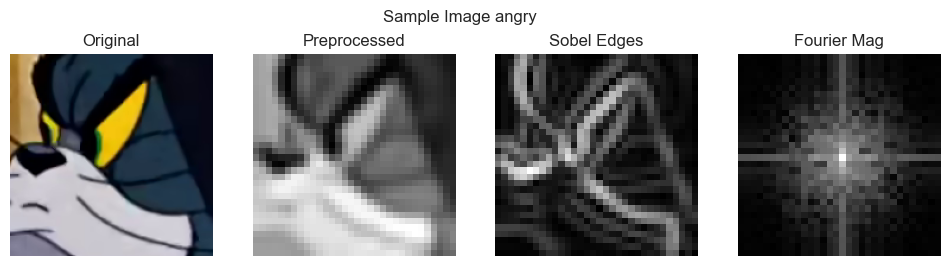

tom - happy


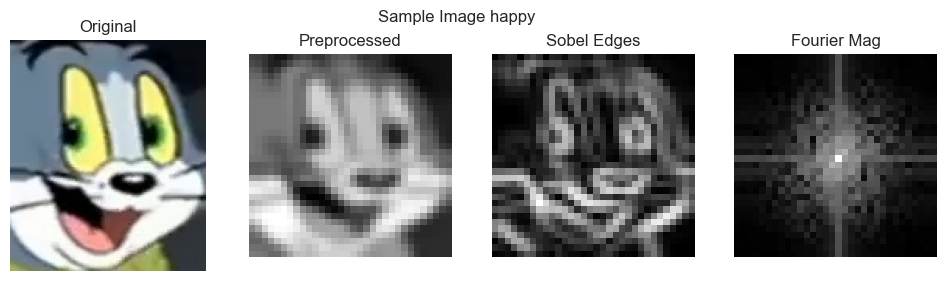

tom - surprised


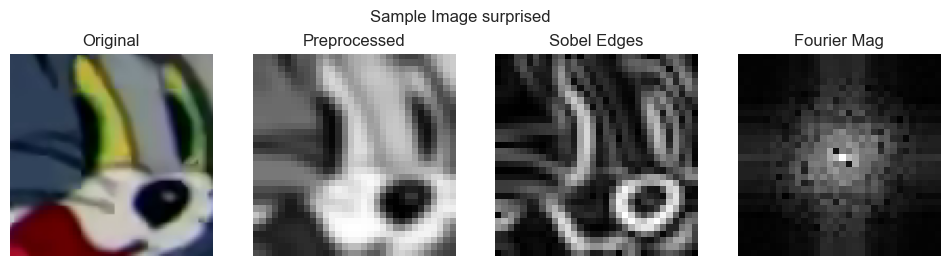

In [5]:
visualize_one_sample_per_emotion(
    character_dir="emotion_dataset/tom",
    visualize_fn=visualize_features
)

jerry - angry


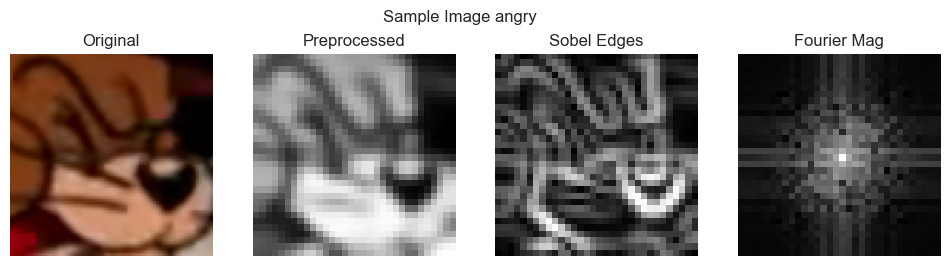

jerry - happy


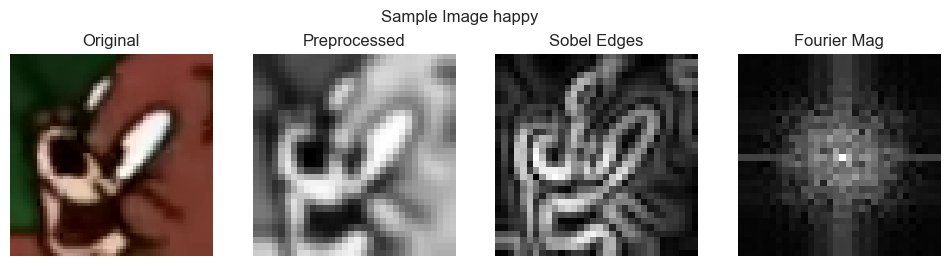

jerry - surprised


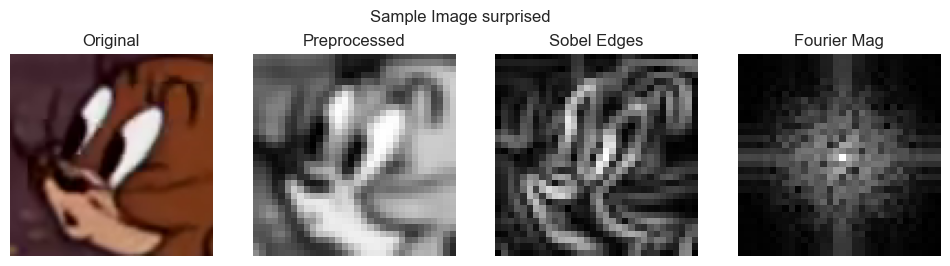

In [6]:
visualize_one_sample_per_emotion(
    character_dir="emotion_dataset/jerry",
    visualize_fn=visualize_features
)

## Load Entire Dataset and Extract Features

In [7]:
def load_character_data(character_dir):
    features_list = []
    labels = []
    image_paths = []

    emotion_names = sorted(
        [d for d in os.listdir(character_dir) if os.path.isdir(os.path.join(character_dir, d))]
    )
    label_to_index = {name: idx for idx, name in enumerate(emotion_names)}

    for emotion in emotion_names:
        folder = os.path.join(character_dir, emotion)
        label_idx = label_to_index[emotion]

        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue

            image = cv2.resize(image, IMG_SIZE)
            preprocessed = preprocess_image(image)
            features = extract_features(preprocessed)

            features_list.append(features)
            labels.append(label_idx)
            image_paths.append(img_path)

    return (
        np.array(features_list),
        np.array(labels),
        image_paths,
        emotion_names
    )

print("Loading and processing Tom dataset...")
X_tom, y_tom, tom_paths, tom_labels = load_character_data("emotion_dataset/tom")
print("Feature vector size:", X_tom.shape[1])

print()

print("Loading and processing Jerry dataset...")
X_jerry, y_jerry, jerry_paths, jerry_labels = load_character_data("emotion_dataset/jerry")
print("Feature vector size:", X_jerry.shape[1])

Loading and processing Tom dataset...
Feature vector size: 2116

Loading and processing Jerry dataset...
Feature vector size: 2116


## Split Dataset and Train Manual KNN

In [8]:
X_tom_train, X_tom_test, y_tom_train, y_tom_test, tom_train_paths, tom_test_paths = train_test_split(
    X_tom, y_tom, tom_paths,
    test_size=0.2,
    stratify=y_tom,
    random_state=42
)

X_jerry_train, X_jerry_test, y_jerry_train, y_jerry_test, jerry_train_paths, jerry_test_paths = train_test_split(
    X_jerry, y_jerry, jerry_paths,
    test_size=0.2,
    stratify=y_jerry,
    random_state=42
)

def predict_knn(X_train, y_train, test_features, k_neighbors):
    distances = np.linalg.norm(X_train - test_features, axis=1)
    nearest_idx = np.argsort(distances)[:k_neighbors]
    nearest_labels = y_train[nearest_idx]
    unique, counts = np.unique(nearest_labels, return_counts=True)
    return unique[np.argmax(counts)]

def knn_predict_batch(X_train, y_train, X_test, k):
    return np.array([
        predict_knn(X_train, y_train, x, k) for x in X_test
    ])

# Predict on test set
y_tom_pred = knn_predict_batch(X_tom_train, y_tom_train, X_tom_test, K_NEIGHBORS)
y_jerry_pred = knn_predict_batch(X_jerry_train, y_jerry_train, X_jerry_test, K_NEIGHBORS)

## Evaluate Model
- Overall accuracy
- Classification report (precision, recall, f1-score)
- Confusion matrix

In [9]:
def evaluate_model(y_true, y_pred, label_names, title_prefix=""):
    """
    Evaluate a classifier using accuracy, classification report,
    and confusion matrix visualization.
    """
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"{title_prefix} Model Accuracy: {accuracy * 100:.2f}%\n")

    # Classification report
    print(f"{title_prefix} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.show()

    return accuracy

Tom Model Accuracy: 60.00%

Tom Classification Report:
              precision    recall  f1-score   support

       angry       0.68      0.70      0.69        40
       happy       0.51      0.62      0.56        40
   surprised       0.63      0.47      0.54        40

    accuracy                           0.60       120
   macro avg       0.61      0.60      0.60       120
weighted avg       0.61      0.60      0.60       120



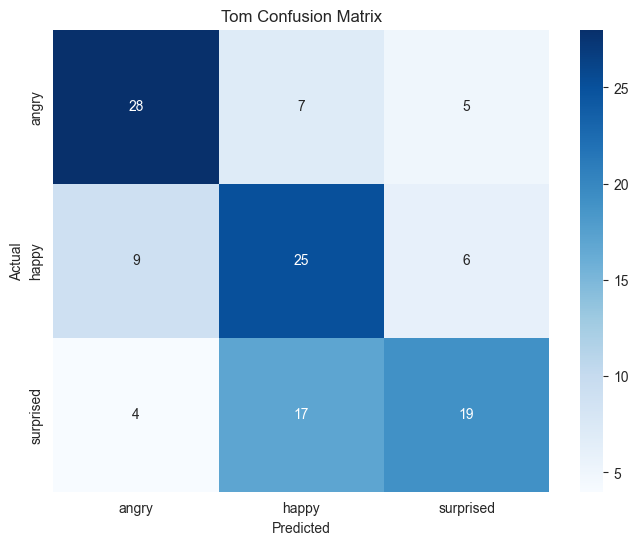

0.6

In [10]:
evaluate_model(
    y_true=y_tom_test,
    y_pred=y_tom_pred,
    label_names=tom_labels,
    title_prefix="Tom"
)

Jerry Model Accuracy: 54.29%

Jerry Classification Report:
              precision    recall  f1-score   support

       angry       0.63      0.63      0.63        35
       happy       0.38      0.40      0.39        35
   surprised       0.64      0.60      0.62        35

    accuracy                           0.54       105
   macro avg       0.55      0.54      0.55       105
weighted avg       0.55      0.54      0.55       105



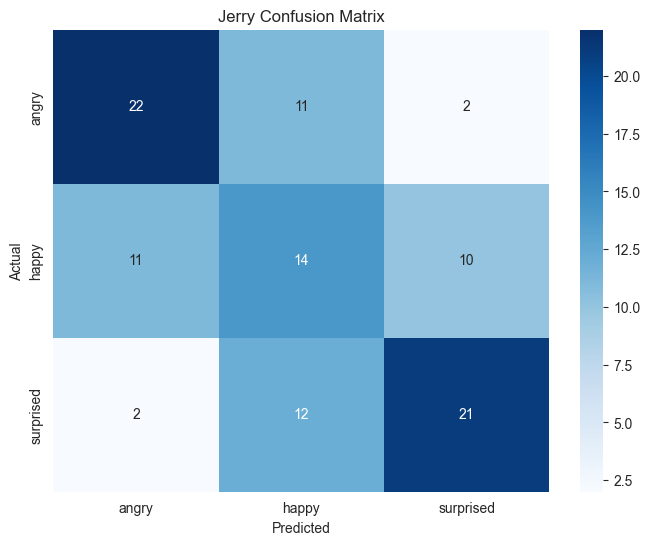

0.5428571428571428

In [11]:
evaluate_model(
    y_true=y_jerry_test,
    y_pred=y_jerry_pred,
    label_names=jerry_labels,
    title_prefix="Jerry"
)

## Sample Predictions

Showing some test images with their predicted vs real labels to visually inspect model performance.

In [33]:
def show_sample_predictions(
    image_paths,
    y_test,
    y_pred,
    label_names,
    num_samples=12,
    title_prefix=""
):
    """
    Visualize sample predictions in a grid layout.
    """
    num_samples = min(num_samples, len(image_paths))

    cols = 4
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    fig.suptitle(f"{title_prefix} - Sample Predictions", fontsize=16, y=0.995)

    # Flatten axes array for easier indexing
    axes = axes.flatten()

    for i in range(num_samples):
        img_path = image_paths[i]

        # Load image
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display in subplot
        axes[i].imshow(img)
        axes[i].set_title(
            f"Real: {label_names[y_test[i]]}\nPred: {label_names[y_pred[i]]}",
            fontsize=10
        )
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(num_samples, rows * cols):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

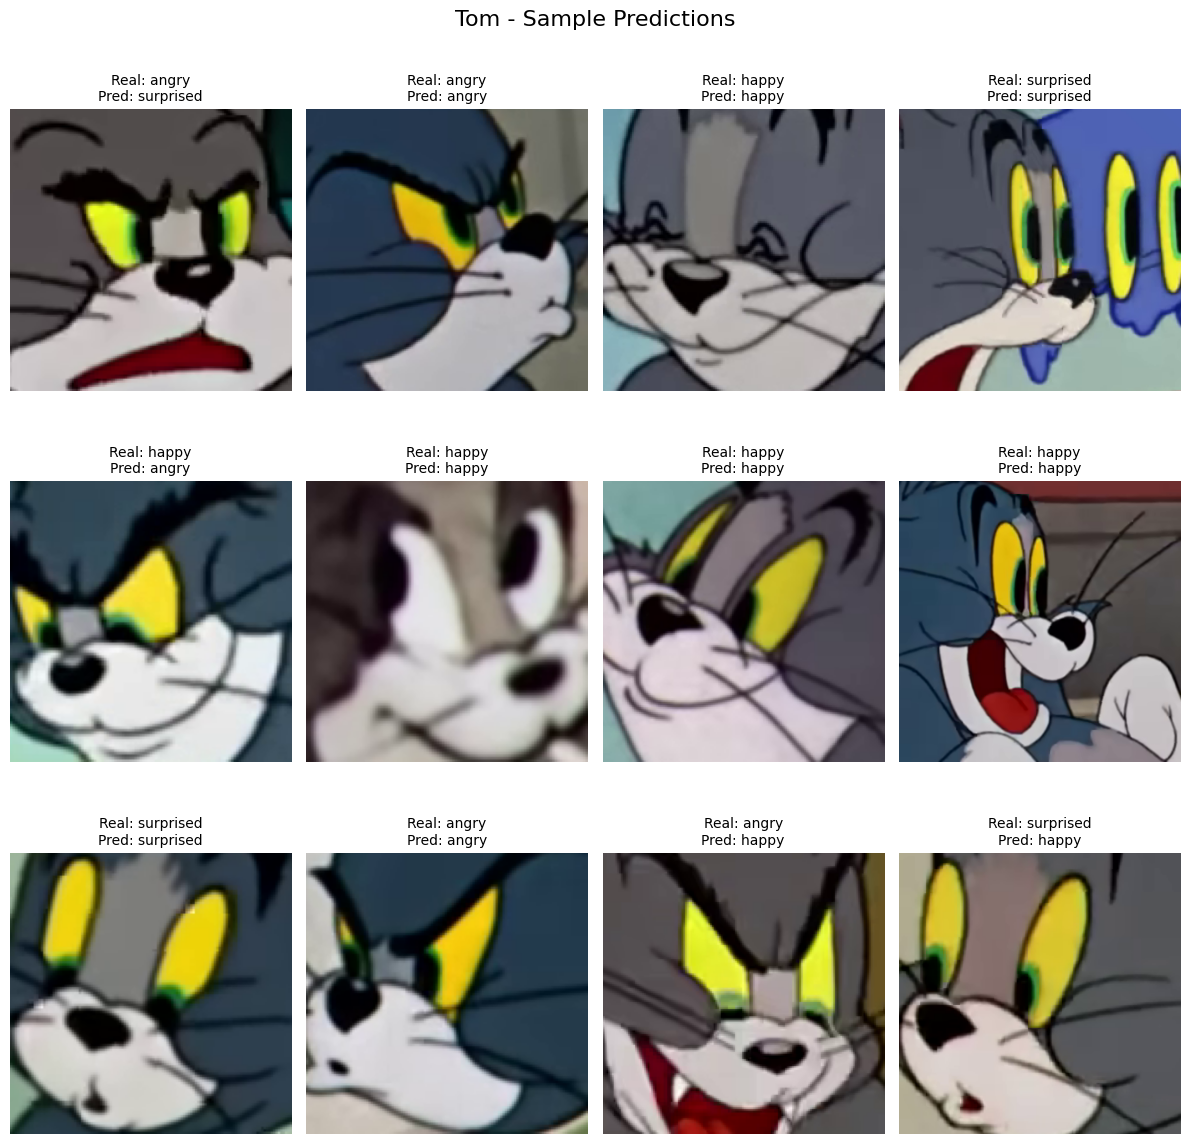

In [34]:
show_sample_predictions(
    image_paths=tom_test_paths,
    y_test=y_tom_test,
    y_pred=y_tom_pred,
    label_names=tom_labels,
    num_samples=12,
    title_prefix="Tom"
)

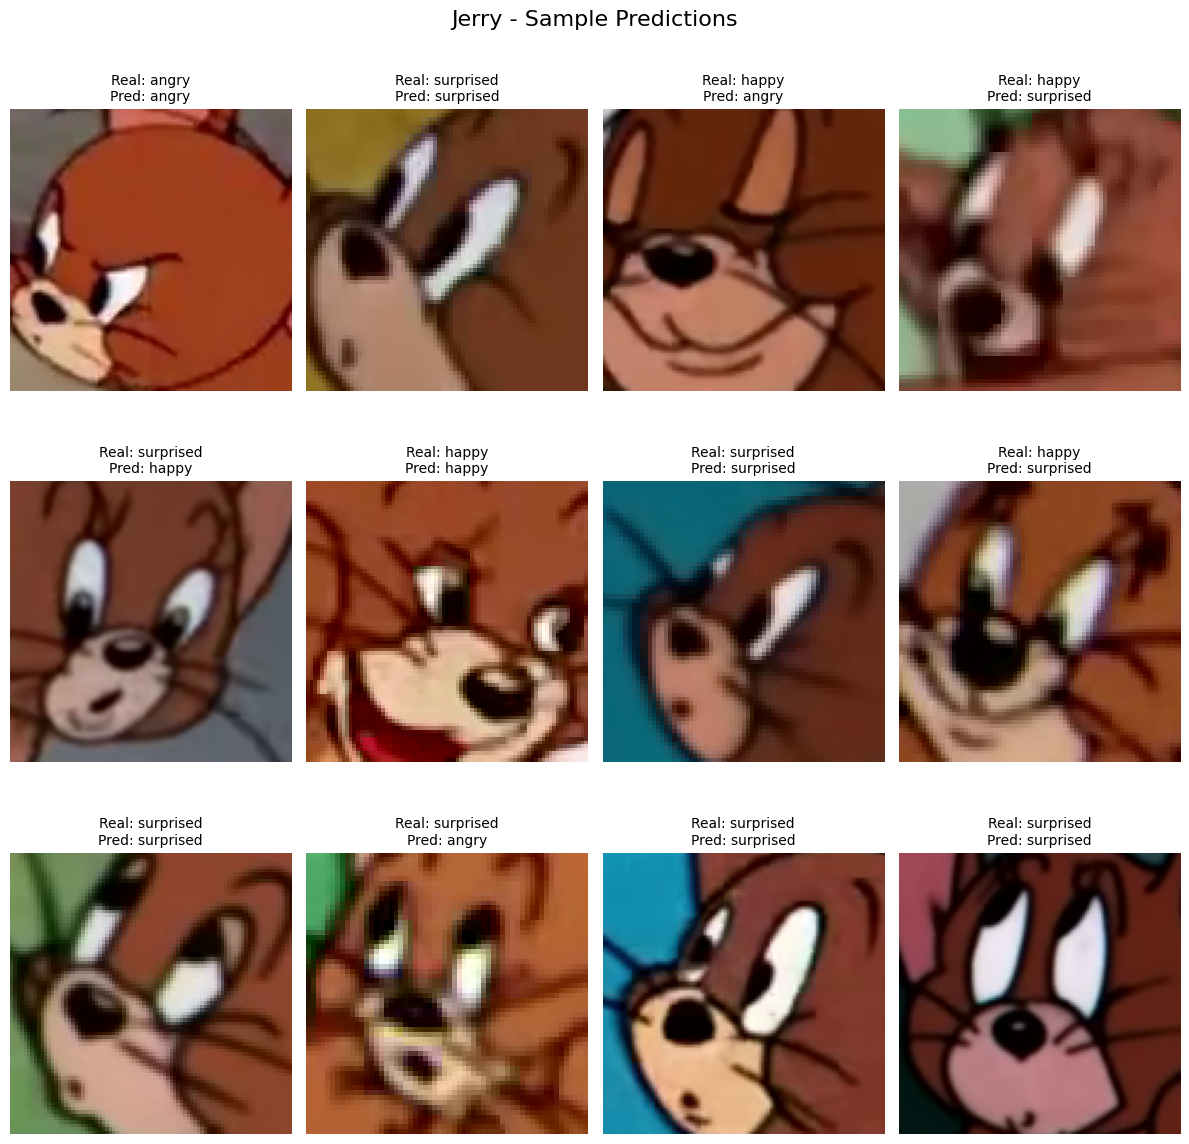

In [35]:
show_sample_predictions(
    image_paths=jerry_test_paths,
    y_test=y_jerry_test,
    y_pred=y_jerry_pred,
    label_names=jerry_labels,
    num_samples=12,
    title_prefix="Jerry"
)

## Save Model and Features

Saving the processed dataset and label mapping for future use or inference.

In [36]:
if not os.path.isdir(MODEL_DIR): os.mkdir(MODEL_DIR)

np.savez(os.path.join(MODEL_DIR, 'knn_data_enhanced_tom.npz'), X_data=X_tom, y_data=y_tom)
joblib.dump(tom_labels, os.path.join(MODEL_DIR, 'knn_tom_labels.pkl'))

np.savez(os.path.join(MODEL_DIR, 'knn_data_enhanced_jerry.npz'), X_data=X_jerry, y_data=y_jerry)
joblib.dump(tom_labels, os.path.join(MODEL_DIR, 'knn_jerry_labels.pkl'))

print("Saved feature data and labels. Training complete!")

Saved feature data and labels. Training complete!
